In [5]:
!pip install diffusers transformers accelerate torch



In [6]:
from huggingface_hub import login
login("YOUR-TOKEN-HERE")

In [7]:
from diffusers import StableDiffusionPipeline
import torch

# Load the model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()  # Saves memory
print("Model loaded successfully!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


Generating image... please wait ⏳


  0%|          | 0/50 [00:00<?, ?it/s]

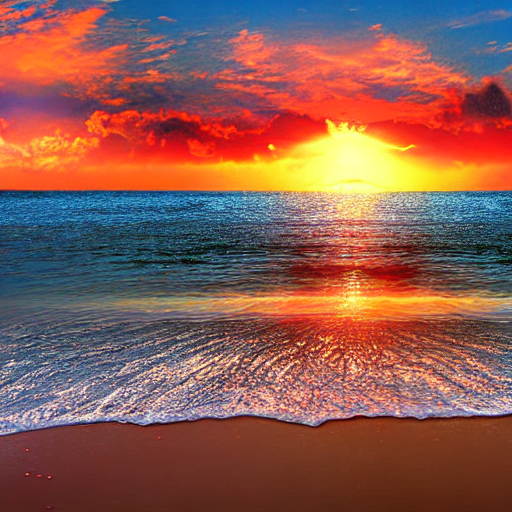

✅ Image saved!


In [8]:
from IPython.display import display

prompt = "a beautiful sunset over the ocean, digital art"

print("Generating image... please wait ⏳")
image = pipe(prompt).images[0]
display(image)
image.save("my_first_image.png")
print("✅ Image saved!")


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

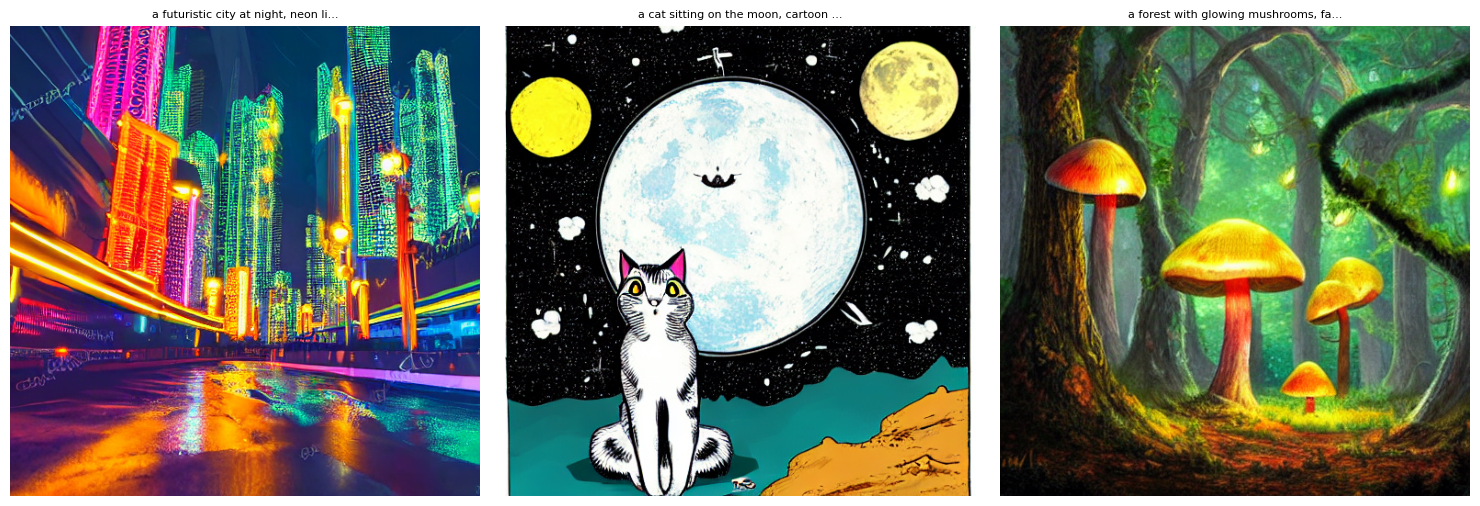

Done!


In [9]:
import matplotlib.pyplot as plt

prompts = [
    "a futuristic city at night, neon lights",
    "a cat sitting on the moon, cartoon style",
    "a forest with glowing mushrooms, fantasy art"
]

images = []
for prompt in prompts:
    image = pipe(prompt).images[0]
    images.append(image)

# Show all images together
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (img, prompt) in enumerate(zip(images, prompts)):
    axes[i].imshow(img)
    axes[i].set_title(prompt[:35] + "...", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("all_results.png")
plt.show()
print("Done!")

In [10]:
# Save each image separately
for i, image in enumerate(images):
    image.save(f"image_{i+1}.png")
    print(f"✅ Saved image_{i+1}.png")

✅ Saved image_1.png
✅ Saved image_2.png
✅ Saved image_3.png


In [11]:
from google.colab import files

files.download("image_1.png")
files.download("image_2.png")
files.download("image_3.png")
files.download("all_results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>